Loading Dataset

In [1]:
!pip install transformers datasets torch scikit-learn

In [2]:
from datasets import load_dataset

dataset = load_dataset("csv", data_files="IMDB Dataset.csv")

Text Cleaning

In [3]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

dataset = dataset.map(lambda x: {"review_cleaned": clean_text(x["review"])})

Label Conversion & Train-Test Split

In [4]:
def convert_labels(example):
    # Assuming the sentiment column is named 'sentiment' and contains 'positive' or 'negative'
    example["labels"] = 1 if example["sentiment"] == "positive" else 0
    return example

# Apply the label conversion to the dataset before splitting
dataset = dataset.map(convert_labels)

dataset = dataset["train"].train_test_split(test_size=0.2)
train_dataset = dataset["train"]
val_dataset = dataset["test"]

Tokenization

In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(example["review_cleaned"], truncation=True, padding=True, max_length=256)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [6]:
train_dataset = train_dataset.remove_columns(["review"])
val_dataset = val_dataset.remove_columns(["review"])

In [7]:
train_dataset = train_dataset.remove_columns(["sentiment", "review_cleaned"])
val_dataset = val_dataset.remove_columns(["sentiment", "review_cleaned"])

In [8]:
train_dataset.set_format("torch")
val_dataset.set_format("torch")

In [9]:
print(val_dataset.column_names)

['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [10]:
print(train_dataset[0])

{'labels': tensor(0), 'input_ids': tensor([  101,  4593,  1996,  2143,  2038,  1037,  8401,  3424,  5747,  4471,
         2065,  2009,  2515,  1045,  2134,  1056,  2131,  2009,  2008,  1055,
         2035,  2009,  2003,  2009,  1055, 11771,  1998, 11809,  2558,  2009,
         1055,  2205,  3809,  2012,  2335,  2000,  2022,  1037,  4038,  2205,
         4030,  2000,  2022,  1037, 10874,  2025,  6057,  2025, 13940,  2025,
        10990,  2025,  2143,  2009,  1055,  2205,  2673,  2000,  2022,  1996,
         4500,  1998, 25292,  2063, 18601,  1045,  2001, 15261,  2012,  2129,
         2919,  1037,  2143,  2071, 11891,  2123,  1056,  2130,  2228,  1997,
         3666,  2009,  1045,  2031,  3427,  6719,  5606,  1997,  3152,  1998,
         2196,  2031,  1045,  2042,  2061, 14723,  2000,  4339,  1037,  5432,
         2006, 10047, 18939,  4468,  2012,  2035,  5366,  2017,  2031,  2042,
         7420,  2130,  1996,  2437,  1997,  2003, 16267, 11771,  2009,  1055,
         2074,  2111,  3331, 

Model Loading

In [11]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Setup

In [12]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch"
)

Freeze BERT

In [13]:
##for param in model.bert.parameters():
  #  param.requires_grad = False

Fine-tune Last 2 Layers

In [14]:
# Freeze only embeddings (lighter freeze)
for name, param in model.named_parameters():
    if "embeddings" in name:
        param.requires_grad = False
    else:
        param.requires_grad = True

Metrics

In [15]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

Trainer

In [16]:
from transformers import Trainer, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,   # updated dataset
    eval_dataset=val_dataset,      # updated dataset
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

Prediction

In [17]:
preds = trainer.predict(val_dataset)

Confusion Matrix

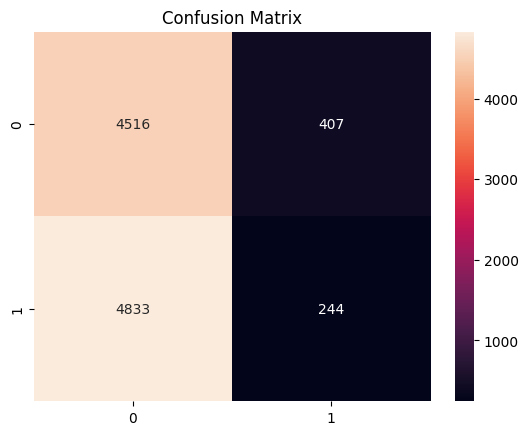

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = preds.predictions.argmax(axis=1)
y_true = preds.label_ids

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()